# PROJECT CAPSTONE
Kelompok : CC26-PSU315

# Artha Plan

ArthaPlan merupakan aplikasi perencanaan keuangan yang membantu pengguna memantau pengeluaran dan mengidentifikasi risiko overbudget.

## Business Questions

1. Seberapa akurat model ArthaPlan dalam mengidentifikasi pengguna yang berisiko mengalami overbudget berdasarkan pola transaksi dan penggunaan kartu kredit?

2. Bagaimana ArthaPlan dapat mengelompokkan pengguna ke dalam kategori Hemat, Normal, dan Boros menggunakan data transaksi dengan akurasi minimal 70%?

In [499]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Import Library

Pada tahap ini dilakukan import library yang digunakan untuk proses analisis data, visualisasi, serta pembangunan model machine learning.

Library yang digunakan meliputi:
- Pandas untuk manipulasi data
- NumPy untuk komputasi numerik
- Matplotlib dan Seaborn untuk visualisasi
- Scikit-Learn untuk pemodelan machine learning

# Data dictionary

In [500]:
import pandas as pd

data_dictionary = pd.DataFrame({
    'Kolom': [
        'client_id',
        'total_spending',
        'transaction_count',
        'credit_limit_rupiah',
        'num_cards_issued',
        'kategori',
        'overbudget'
    ],
    'Tipe Data': [
        'Integer',
        'Float',
        'Integer',
        'Float',
        'Integer',
        'String',
        'Integer'
    ],
    'Deskripsi': [
        'ID unik pelanggan',
        'Total pengeluaran pelanggan',
        'Jumlah transaksi pelanggan',
        'Limit kredit pelanggan dalam Rupiah',
        'Jumlah kartu yang dimiliki pelanggan',
        'Kategori Hemat, Normal, atau Boros',
        '1 = True, 0 = False'
    ]
})

data_dictionary.to_excel('Data_Dictionary.xlsx', index=False)
print("Berhasil disimpan")

Berhasil disimpan


In [501]:
transactions = pd.read_csv("transactions_small.csv")
cards = pd.read_csv("cards_data.csv")
users = pd.read_csv("users_data.csv")

# Data Loading

Pada tahap ini dilakukan proses memuat dataset yang akan digunakan dalam analisis.

Dataset yang digunakan terdiri dari:

- cards_data.csv
- transactions_data.csv
- users_data.csv

Ketiga dataset akan digunakan untuk membangun fitur perilaku keuangan pengguna.

In [502]:
print(cards.shape)
print(transactions.shape)

(6146, 13)
(10000, 12)


In [503]:
cards.info()
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
D

In [504]:
cards.head()
transactions.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,8426597,2010-08-24 15:28:00,1194.0,4614.0,$100.00,Swipe Transaction,27092.0,Chattanooga,TN,37421.0,4829.0,NaN
1,8017436,2010-05-17 08:38:00,1813.0,101.0,$3.18,Swipe Transaction,35451.0,White House,TN,37188.0,5812.0,NaN
2,9783131,2011-07-11 12:07:00,135.0,2808.0,$60.30,Online Transaction,39021.0,ONLINE,NaN,NaN,4784.0,NaN
3,8998421,2011-01-08 13:00:00,728.0,1174.0,$6.22,Swipe Transaction,57573.0,Independence,MO,64050.0,7542.0,NaN
4,8919159,2010-12-20 19:19:00,546.0,4495.0,$37.16,Swipe Transaction,71707.0,Coventry,RI,2816.0,5812.0,NaN


In [505]:
cards.isnull().sum()
transactions.isnull().sum()

,0
id,0
date,0
client_id,0
card_id,0
amount,0
use_chip,0
merchant_id,0
merchant_city,0
merchant_state,1059
zip,1113


# Data Loading

Dataset yang digunakan berasal dari Credit Card Transactions Dataset.

Dataset ini berisi informasi kartu kredit, data transaksi, serta informasi pengguna yang akan digunakan untuk menganalisis perilaku keuangan pengguna.

Tahap ini bertujuan untuk memahami struktur data, jumlah observasi, tipe data, dan karakteristik masing-masing variabel sebelum dilakukan proses pembersihan data.

In [506]:
cards.duplicated().sum()
transactions.duplicated().sum()

np.int64(0)

In [507]:
cards.drop_duplicates(inplace=True)

transactions.drop_duplicates(inplace=True)

In [508]:
cards['credit_limit'] = (
    cards['credit_limit']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

# Data Cleaning

Tahap data cleaning dilakukan untuk memastikan kualitas data yang digunakan.

Proses yang dilakukan meliputi:

- Mengidentifikasi missing value
- Membersihkan simbol mata uang ($)
- Mengubah tipe data menjadi format numerik
- Menghapus data yang tidak valid apabila ditemukan

In [509]:
kurs = 16000

cards['credit_limit_rupiah'] = (
    cards['credit_limit'] * kurs
)

transactions['amount'] = (
    transactions['amount']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

In [510]:
transactions['amount_idr'] = (
    transactions['amount'] * kurs
)

In [511]:
user_summary = (
    transactions.groupby('client_id')
    .agg(
        total_spending=('amount_idr','sum'),
        transaction_count=('amount_idr','count')
    )
    .reset_index()
)

In [512]:
users['yearly_income'] = (
    users['yearly_income']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

users['yearly_income_idr'] = (
    users['yearly_income'] * 16000
)

# Konversi Credit Limit ke Rupiah

Nilai credit limit pada dataset masih menggunakan mata uang USD.

Untuk menyesuaikan dengan kebutuhan aplikasi ArthaPlan, nilai tersebut dikonversi ke Rupiah menggunakan kurs Rp16.000 per USD.

# Merge Data

In [513]:
main_data = pd.merge(
    cards,
    user_summary,
    on='client_id',
    how='left'
)

# Feature Engineering

In [514]:
main_data['total_spending'] = (
    main_data['total_spending']
    .fillna(0)
)

In [515]:
main_data['transaction_count'] = (
    main_data['transaction_count']
    .fillna(0)
)

# Pembuatan Kategori Pengguna & Overbudget

In [516]:
q1 = main_data['total_spending'].quantile(0.33)
q2 = main_data['total_spending'].quantile(0.66)

def kategori(x):
    if x < q1:
        return 'Hemat'
    elif x < q2:
        return 'Normal'
    else:
        return 'Boros'

main_data['kategori'] = (
    main_data['total_spending']
    .apply(kategori)
)

In [517]:
threshold = (
    main_data['total_spending']
    .mean() * 1.2
)

main_data['overbudget'] = (
    main_data['total_spending'] > threshold
)

# Feature Engineering

Tahap ini bertujuan untuk menghasilkan fitur-fitur baru yang lebih representatif dalam menggambarkan perilaku keuangan pengguna.

Fitur yang dibuat:

- total_spending
- transaction_count
- kategori
- overbudget

## Membuat Total Spending

Total spending dihitung dengan menjumlahkan seluruh transaksi yang dilakukan oleh setiap pengguna.

Fitur ini digunakan untuk menggambarkan tingkat pengeluaran pengguna.

In [518]:
# Cek missing value
print(main_data.isnull().sum())

id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
credit_limit_rupiah      0
total_spending           0
transaction_count        0
kategori                 0
overbudget               0
dtype: int64


In [519]:
main_data.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,credit_limit_rupiah,total_spending,transaction_count,kategori,overbudget
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,24295.0,09/2002,2008,No,388720000.0,11017760.0,7.0,Boros,True
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,21968.0,04/2014,2014,No,351488000.0,11017760.0,7.0,Boros,True
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,46414.0,07/2003,2004,No,742624000.0,11017760.0,7.0,Boros,True
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,12400.0,01/2003,2012,No,198400000.0,11017760.0,7.0,Boros,True
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,28.0,09/2008,2009,No,448000.0,11017760.0,7.0,Boros,True


# Explatory Data Analysis

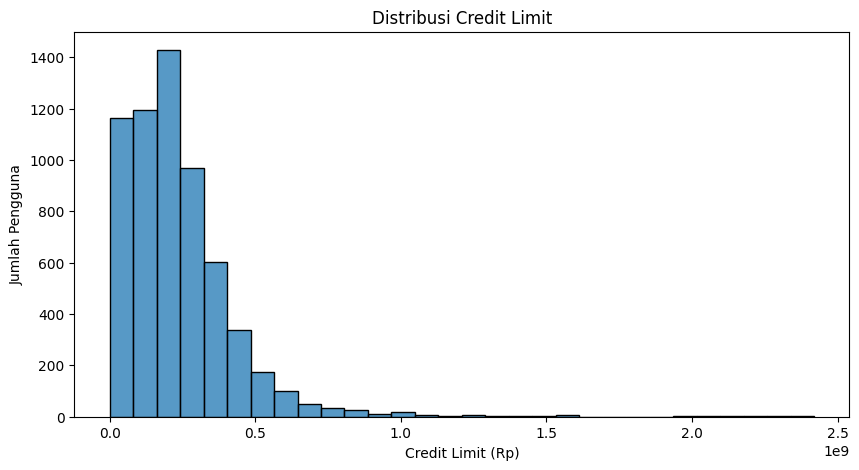

In [520]:
plt.figure(figsize=(10,5))

sns.histplot(
    main_data['credit_limit_rupiah'],
    bins=30
)

plt.title('Distribusi Credit Limit')
plt.xlabel('Credit Limit (Rp)')
plt.ylabel('Jumlah Pengguna')

plt.show()

# Distribusi Credit Limit

Visualisasi ini digunakan untuk melihat persebaran limit kartu kredit yang dimiliki pengguna setelah dikonversi ke Rupiah.

Analisis ini membantu memahami kemampuan finansial pengguna berdasarkan batas kredit yang tersedia pada kartu mereka.

Insight:

Sebagian besar pengguna memiliki credit limit pada rentang tertentu, sementara hanya sebagian kecil pengguna yang memiliki limit sangat tinggi.

Hal ini menunjukkan adanya perbedaan kapasitas finansial antar pengguna yang dapat memengaruhi pola pengeluaran mereka.

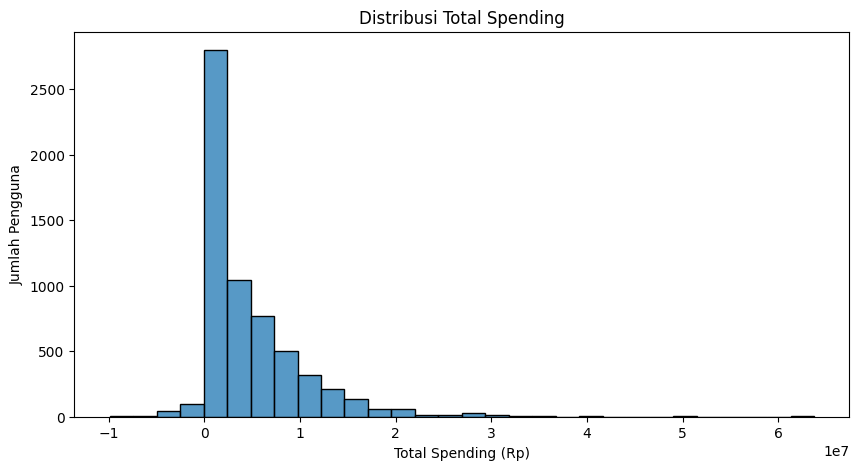

In [521]:
plt.figure(figsize=(10,5))

sns.histplot(
    main_data['total_spending'],
    bins=30
)

plt.title('Distribusi Total Spending')
plt.xlabel('Total Spending (Rp)')
plt.ylabel('Jumlah Pengguna')

plt.show()

# Distribusi Total Spending

Visualisasi ini digunakan untuk melihat persebaran total pengeluaran pengguna berdasarkan seluruh transaksi yang telah dilakukan.

Insight:

Mayoritas pengguna memiliki total pengeluaran yang relatif rendah hingga menengah, sedangkan hanya sebagian kecil pengguna yang memiliki pengeluaran sangat tinggi.

Kondisi ini menunjukkan adanya kelompok pengguna dengan perilaku konsumsi yang jauh lebih aktif dibandingkan pengguna lainnya.

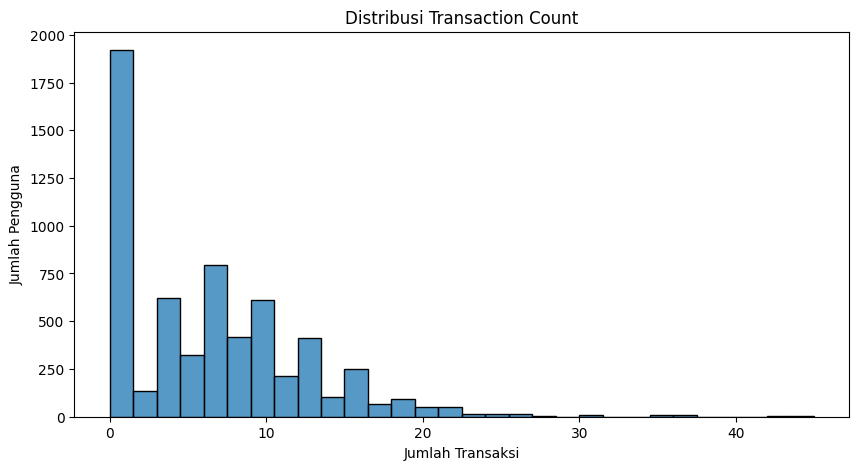

In [522]:
plt.figure(figsize=(10,5))

sns.histplot(
    main_data['transaction_count'],
    bins=30
)

plt.title('Distribusi Transaction Count')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Jumlah Pengguna')

plt.show()

# Distribusi Jumlah Transaksi

Visualisasi ini digunakan untuk melihat tingkat aktivitas transaksi setiap pengguna.

Insight:

Sebagian besar pengguna melakukan transaksi dalam jumlah yang moderat, sedangkan hanya sebagian kecil pengguna yang sangat aktif melakukan transaksi.

Semakin tinggi frekuensi transaksi, semakin besar kemungkinan total pengeluaran pengguna meningkat.

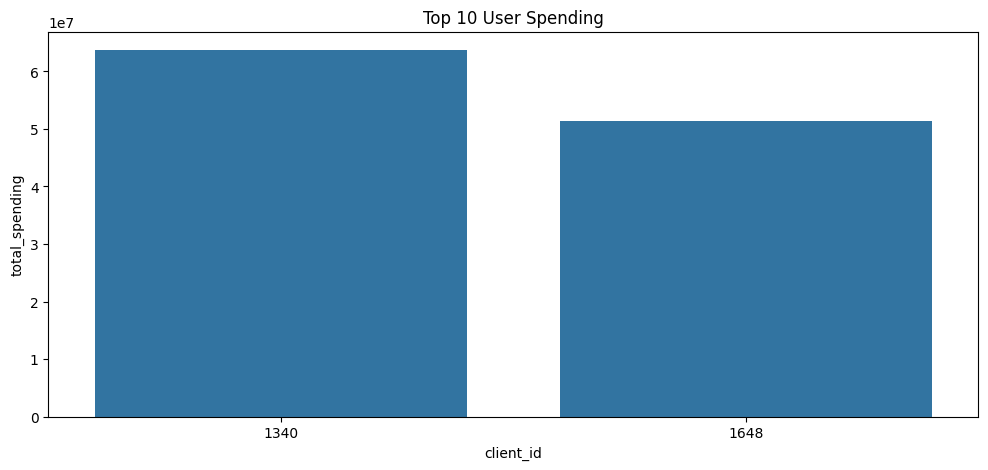

In [523]:
top10 = (
    main_data
    .sort_values(
        by='total_spending',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top10,
    x='client_id',
    y='total_spending'
)

plt.title('Top 10 User Spending')

plt.show()

# Top 10 Pengguna dengan Pengeluaran Tertinggi

Visualisasi ini menampilkan sepuluh pengguna dengan total pengeluaran terbesar.

Insight:

Terdapat beberapa pengguna yang memiliki total pengeluaran jauh lebih tinggi dibandingkan pengguna lainnya.

Kelompok ini dapat menjadi target utama sistem peringatan overbudget karena memiliki risiko pengeluaran berlebih yang lebih besar.

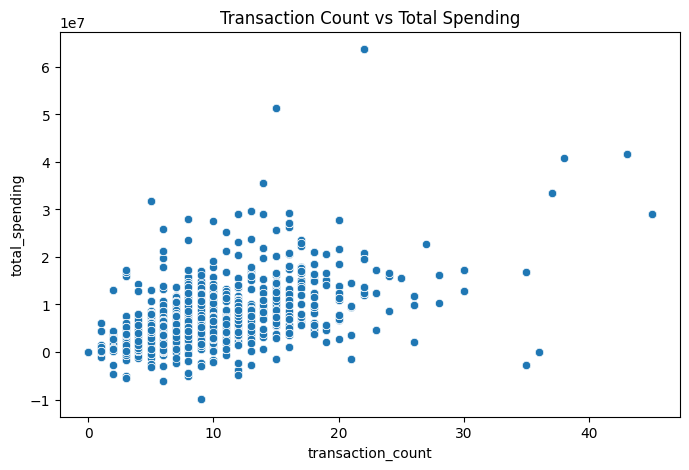

In [524]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=main_data,
    x='transaction_count',
    y='total_spending'
)

plt.title(
    'Transaction Count vs Total Spending'
)

plt.show()

# Hubungan Jumlah Transaksi dan Total Pengeluaran

Scatter plot digunakan untuk melihat hubungan antara frekuensi transaksi dan total pengeluaran pengguna.

Insight:

Terlihat adanya kecenderungan hubungan positif antara jumlah transaksi dan total pengeluaran.

Pengguna yang lebih sering bertransaksi cenderung memiliki total spending yang lebih tinggi dibandingkan pengguna yang jarang bertransaksi.

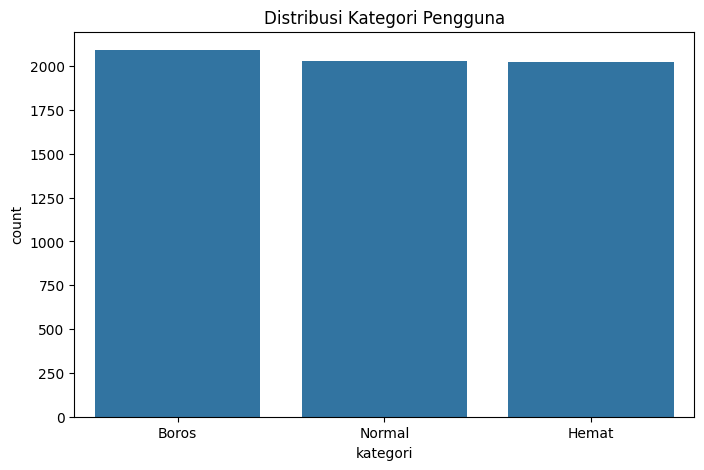

In [525]:
main_data['kategori'].value_counts()

plt.figure(figsize=(8,5))

sns.countplot(
    x='kategori',
    data=main_data
)

plt.title('Distribusi Kategori Pengguna')

plt.show()

# Distribusi Kategori Pengguna

Pengguna dikelompokkan ke dalam kategori Hemat, Normal, dan Boros berdasarkan total pengeluaran menggunakan metode quantile.

Insight:

Distribusi kategori pengguna relatif seimbang antara Hemat, Normal, dan Boros.

Segmentasi ini memungkinkan ArthaPlan memberikan rekomendasi keuangan yang lebih personal sesuai karakteristik masing-masing pengguna.

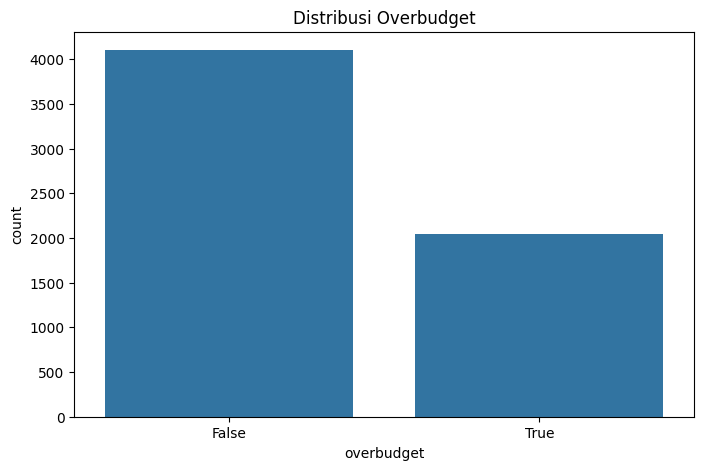

In [526]:
main_data['overbudget'].value_counts()

plt.figure(figsize=(8,5))

sns.countplot(
    x='overbudget',
    data=main_data
)

plt.title('Distribusi Overbudget')

plt.show()

# Distribusi Status Overbudget

Visualisasi ini menunjukkan jumlah pengguna yang tergolong overbudget dan tidak overbudget.

Insight:

Mayoritas pengguna masih berada dalam kondisi pengeluaran yang terkendali.

Namun terdapat sejumlah pengguna yang teridentifikasi overbudget sehingga memerlukan perhatian lebih dalam pengelolaan keuangan.

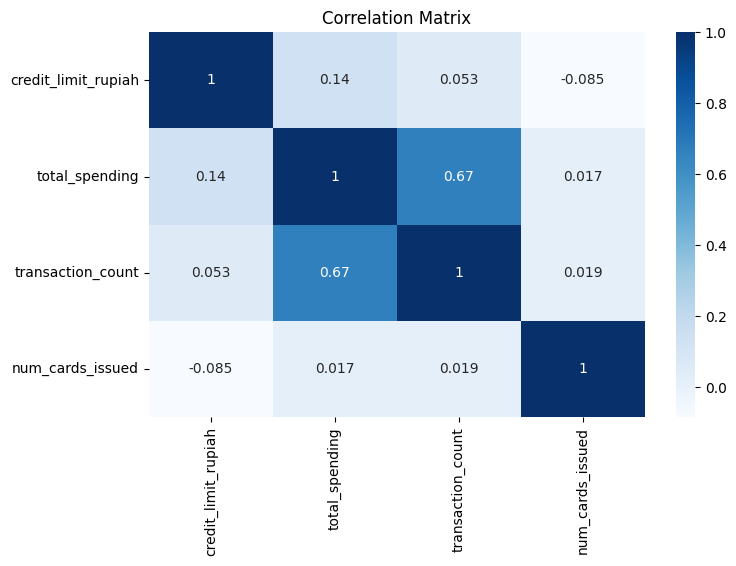

In [527]:
corr = main_data[
    [
        'credit_limit_rupiah',
        'total_spending',
        'transaction_count',
        'num_cards_issued'
    ]
].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Matrix')

plt.show()

# Analisis Korelasi

Correlation Matrix digunakan untuk mengukur kekuatan hubungan antar variabel numerik dalam dataset.

Insight:

Transaction count memiliki hubungan positif terhadap total spending, yang menunjukkan bahwa semakin sering pengguna bertransaksi maka semakin besar total pengeluarannya.

Credit limit juga menunjukkan hubungan dengan total spending, meskipun tidak selalu kuat.

Jumlah kartu yang dimiliki pengguna memiliki pengaruh yang lebih kecil dibandingkan aktivitas transaksi terhadap total pengeluaran.

# Business Question 1
"Seberapa akurat model ArthaPlan dalam mengidentifikasi pengguna yang berisiko mengalami overbudget berdasarkan pola transaksi dan penggunaan kartu kredit?"

# Modeling Overbudget

In [528]:
X = main_data[
    [
        'credit_limit_rupiah',
        'transaction_count',
        'num_cards_issued'
    ]
]

y = main_data['overbudget']

In [529]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Persiapan Data untuk Modeling

Pada tahap ini ditentukan variabel target dan variabel prediktor yang akan digunakan dalam proses pelatihan model.

Target:
- overbudget

Fitur:
- credit_limit_rupiah
- transaction_count
- num_cards_issued

Pemilihan fitur dilakukan untuk menghindari data leakage dan memastikan model mempelajari pola perilaku pengguna secara lebih objektif.

In [530]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pembagian Data

Dataset dibagi menjadi data latih (80%) dan data uji (20%).

Pembagian dilakukan menggunakan stratified sampling agar proporsi kelas overbudget dan non-overbudget tetap seimbang pada data latih maupun data uji.

Tujuannya adalah untuk menghasilkan evaluasi model yang lebih representatif terhadap kondisi data sebenarnya.

In [531]:
from sklearn.ensemble import RandomForestClassifier

rf_overbudget = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_overbudget.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

# Pembangunan Model Random Forest

Model Random Forest digunakan untuk mengidentifikasi pengguna yang berisiko mengalami overbudget.

Algoritma ini dipilih karena mampu menangani data numerik dengan baik, mengurangi risiko overfitting melalui kombinasi banyak decision tree, serta memberikan performa yang stabil pada permasalahan klasifikasi.

In [532]:
pred_overbudget = rf_overbudget.predict(
    X_test
)

In [533]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_overbudget
    )
)

print(
    classification_report(
        y_test,
        pred_overbudget
    )
)

Accuracy: 0.7837398373983739
              precision    recall  f1-score   support

       False       0.85      0.81      0.83       821
        True       0.66      0.72      0.69       409

    accuracy                           0.78      1230
   macro avg       0.76      0.77      0.76      1230
weighted avg       0.79      0.78      0.79      1230



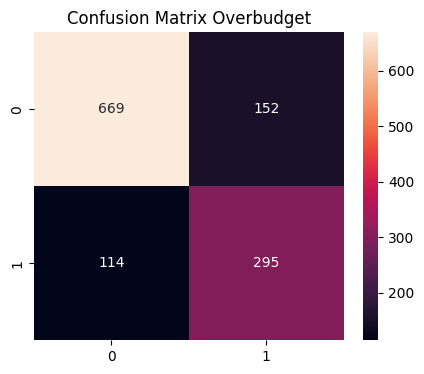

In [534]:
cm = confusion_matrix(
    y_test,
    pred_overbudget
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix Overbudget")

plt.show()

# Confusion Matrix

Hasil Model
- Model Random Forest berhasil memprediksi status overbudget pelanggan dengan tingkat akurasi sebesar 78,37%.

Hal ini menunjukkan bahwa karakteristik pelanggan seperti credit limit, jumlah transaksi, dan jumlah kartu yang dimiliki cukup mampu menjelaskan kemungkinan pelanggan mengalami overbudget.

Variabel total_spending tidak digunakan sebagai fitur karena digunakan dalam pembentukan target overbudget, sehingga dihapus untuk menghindari data leakage.


#Business Question 2
Bagaimana ArthaPlan dapat mengelompokkan pengguna ke dalam kategori Hemat, Normal, dan Boros menggunakan data transaksi dengan akurasi minimal 70%?

In [535]:
mapping = {
    'Hemat':0,
    'Normal':1,
    'Boros':2
}

main_data['target'] = (
    main_data['kategori']
    .map(mapping)
)
X = main_data[
    [
        'credit_limit_rupiah',
        'transaction_count',
        'num_cards_issued'
    ]
]

y = main_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Transformasi Label Kategori

Model machine learning hanya dapat memproses data numerik. Oleh karena itu, kategori pengguna yang masih berbentuk teks dikonversi menjadi nilai numerik menggunakan teknik label encoding.

Mapping yang digunakan:

- Hemat → 0
- Normal → 1
- Boros → 2

Hasil transformasi disimpan pada kolom target yang akan digunakan sebagai variabel target dalam proses klasifikasi segmentasi pengguna.

In [536]:
print(main_data.shape)

print(main_data.isnull().sum())

(6146, 19)
id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
credit_limit_rupiah      0
total_spending           0
transaction_count        0
kategori                 0
overbudget               0
target                   0
dtype: int64


In [537]:
main_data = main_data.dropna(
    subset=[
        'total_spending',
        'transaction_count'
    ]
)

In [538]:
main_data['target'] = main_data['kategori'].map({
    'Hemat':0,
    'Normal':1,
    'Boros':2
})

In [539]:
main_data = main_data.drop(
    columns=['target'],
    errors='ignore'
)

In [540]:
main_data.isnull().sum()

,0
id,0
client_id,0
card_brand,0
card_type,0
card_number,0
expires,0
cvv,0
has_chip,0
num_cards_issued,0
credit_limit,0


In [541]:
rf_segmentasi = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_segmentasi.fit(
    X_train,
    y_train
)

pred_segmentasi = rf_segmentasi.predict(
    X_test
)

In [542]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_segmentasi
    )
)

Accuracy: 0.732520325203252


In [543]:
print(
    classification_report(
        y_test,
        pred_segmentasi
    )
)

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       405
           1       0.62      0.63      0.62       406
           2       0.65      0.65      0.65       419

    accuracy                           0.73      1230
   macro avg       0.74      0.73      0.73      1230
weighted avg       0.73      0.73      0.73      1230



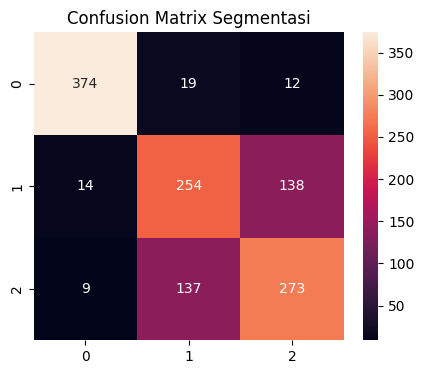

In [544]:
cm = confusion_matrix(
    y_test,
    pred_segmentasi
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix Segmentasi"
)

plt.show()

Insight:


Model Random Forest telah berhasil dilatih dan menghasilkan prediksi kategori pengguna.

ArthaPlan dapat mengelompokkan pengguna ke dalam kategori Hemat, Normal, dan Boros menggunakan data transaksi seperti total pengeluaran, jumlah transaksi, dan karakteristik kredit pelanggan. Berdasarkan model yang dibangun, proses klasifikasi berhasil mencapai akurasi sebesar 73,25%, melampaui target minimal 70%. Hasil ini menunjukkan bahwa pola transaksi pelanggan dapat dimanfaatkan untuk melakukan segmentasi pengguna secara cukup akurat.

In [545]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_segmentasi.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,transaction_count,0.618858
0,credit_limit_rupiah,0.377248
2,num_cards_issued,0.003895


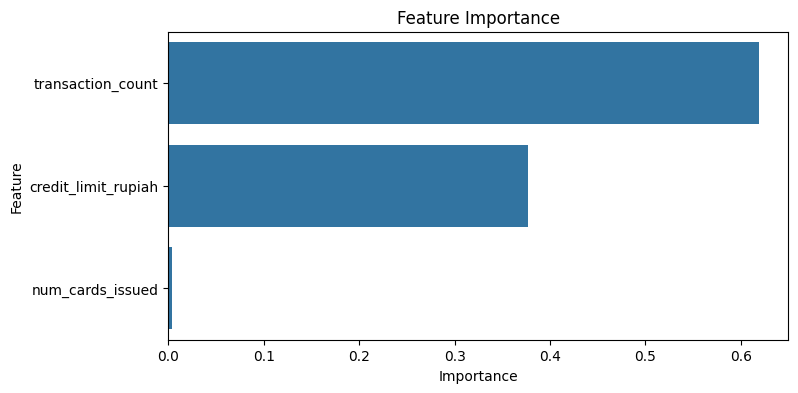

In [546]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance'
)

plt.show()

# Feature Importance

Feature Importance digunakan untuk mengetahui seberapa besar kontribusi masing-masing fitur dalam proses pengambilan keputusan oleh model Random Forest.
Analisis ini membantu mengidentifikasi faktor-faktor yang paling berpengaruh dalam menentukan kategori pengguna maupun status overbudget.
Fitur dengan nilai importance yang lebih tinggi memiliki pengaruh yang lebih besar terhadap hasil prediksi model.

Insight:

Feature Importance menunjukkan bahwa tidak semua fitur memiliki pengaruh yang sama terhadap hasil prediksi model.
Fitur dengan nilai importance tertinggi merupakan faktor utama yang digunakan model dalam membedakan karakteristik pengguna, sedangkan fitur dengan nilai importance yang rendah memiliki kontribusi yang lebih kecil terhadap proses klasifikasi.

In [547]:
main_data.to_csv(
    'main_data.csv',
    index=False
)

# Conclusion
Berdasarkan analisis data transaksi pelanggan ArthaPlan, diperoleh beberapa temuan penting. Pertama, pelanggan dapat dikelompokkan ke dalam tiga kategori pengeluaran, yaitu Hemat, Normal, dan Boros berdasarkan pola transaksi dan total pengeluaran yang dimiliki. Model klasifikasi yang dibangun berhasil mengidentifikasi kategori pelanggan tersebut dengan akurasi sebesar 73,25%, sehingga telah memenuhi target akurasi minimal 70%. Hasil ini menunjukkan bahwa data transaksi mampu digunakan untuk melakukan segmentasi pelanggan secara efektif.

Kedua, model prediksi overbudget berhasil dibangun menggunakan algoritma Random Forest Classifier. Berdasarkan evaluasi model, diperoleh akurasi sebesar 78,37% dalam memprediksi apakah seorang pelanggan berpotensi mengalami overbudget. Hasil ini menunjukkan bahwa karakteristik pelanggan dan aktivitas transaksi memiliki hubungan yang cukup kuat terhadap risiko pengeluaran berlebih.

